Trying to reproduce phase diagrams from: 

- [Quantum correlations, entanglement spectrum and coherence of two-particle reduced density matrix in the Extended Hubbard Model](https://arxiv.org/pdf/2111.00085)

- [Formation of spin and charge ordering in the extended Hubbard model during a finite-time quantum quench](https://arxiv.org/pdf/2208.05945)


- [Entanglement of indistinguishable particles as a probe for quantum phase transitions in the extended Hubbard model](https://arxiv.org/pdf/1503.08188)

In [2]:
from __future__ import print_function, division
import sys,os
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import pandas as pd

from mpl_toolkits.mplot3d import Axes3D

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import cbook
import imageio
import os

%matplotlib inline 
font = {
        'weight' : 'bold',
        'size'   : 16}
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', **font) 

figures_path = "../figs"
model = "EHM_Itensor" 
exec = "Phase_Diagram"
results = "../results"
theme = "viridis"

is_pairs = False

In [3]:
N_Points = 70
L = 10

In [4]:
# Order parameters
def m_SDW(L, Sj): 
    m_sdw = 0
    for j in range(L):
        m_sdw += (-1)**(j) * (Sj[j])
    return m_sdw / L

def m_CDW(L, nj):
    m_cdw = 0
    for j in range(L):
        m_cdw += (-1)**(j) * (nj[j] - 1)
    return m_cdw / L 

In [5]:
def load_scalar_data(results, model, exec, L, N_Points, is_pairs):
    if is_pairs: 
        info_input = f"{results}/{model}_{exec}/scalars_{model}_{exec}_L={L}_NPoints={N_Points}_pairs.csv"

        df = pd.read_csv(info_input)

        Q_2 = df['Q_2'].values
        Q_2_bits = df['Q_2_bits'].values

        quantum_coherence_1 = df['coh_1rdm'].values
        quantum_coherence_2 = df['coh_2rdm'].values

        E_p = df['E_p'].values
        E_p_bits = df['E_p_bits'].values
        E_GS = df['E_GS'].values

        m_sdw = abs(df['m_sdw'].values)
        m_cdw = abs(df['m_cdw'].values)
        
        avg_linear_entropy = df['S'].values

        return U_vals, V_vals, m_sdw, m_cdw, avg_linear_entropy, E_GS, E_p, E_p_bits, quantum_coherence_1, Q_2, Q_2_bits, quantum_coherence_2
    else: 
        info_input = f"{results}/{model}_{exec}/scalars_{model}_{exec}_L={L}_NPoints={N_Points}.csv"
        df = pd.read_csv(info_input)

        U_vals = np.sort(df['U'].unique())
        V_vals = np.sort(df['V'].unique())

        U_unique = np.sort(df['U'].unique())
        V_unique = np.sort(df['V'].unique())

        nU = len(U_vals)
        nV = len(V_vals)
        
        Q_2 = df['Q_2'].values.reshape(nV, nU).T
        Q_2_bits = df['Q_2_bits'].values.reshape(nV, nU).T

        quantum_coherence_1 = df['coh_1rdm'].values.reshape(nV, nU).T
        quantum_coherence_2 = df['coh_2rdm'].values.reshape(nV, nU).T

        E_p = df['E_p'].values.reshape(nV, nU).T
        E_p_bits = df['E_p_bits'].values.reshape(nV, nU).T
        E_GS = df['E_GS'].values.reshape(nV, nU).T

        m_sdw = abs(df['m_sdw'].values.reshape(nV, nU).T)
        m_cdw = abs(df['m_cdw'].values.reshape(nV, nU).T)

        avg_linear_entropy = df['S'].values.reshape(nV, nU).T

        return U_vals, V_vals, U_unique, V_unique, m_sdw, m_cdw, avg_linear_entropy, E_GS, E_p, E_p_bits, quantum_coherence_1, Q_2, Q_2_bits, quantum_coherence_2

In [6]:
U_vals, V_vals, U_unique, V_unique, m_sdw, m_cdw, avg_linear_entropy, E_GS, E_p, E_p_bits, quantum_coherence_1, Q_2, Q_2_bits, quantum_coherence_2 = load_scalar_data(results, model, exec, L, N_Points, is_pairs)

U_min, U_max = U_vals.min(), U_vals.max()
V_min, V_max = V_vals.min(), V_vals.max()

nU, nV = len(U_vals), len(V_vals)

Don't know why, but this order parameters computed in the julia code give the wrong $|m_{\text{SDW}}|$ and $|m_{\text{CDW}}|$...
Saving the magnetization and charge density made possible to compute in python.

### Order parameters for spin-density wave and charge-density wave

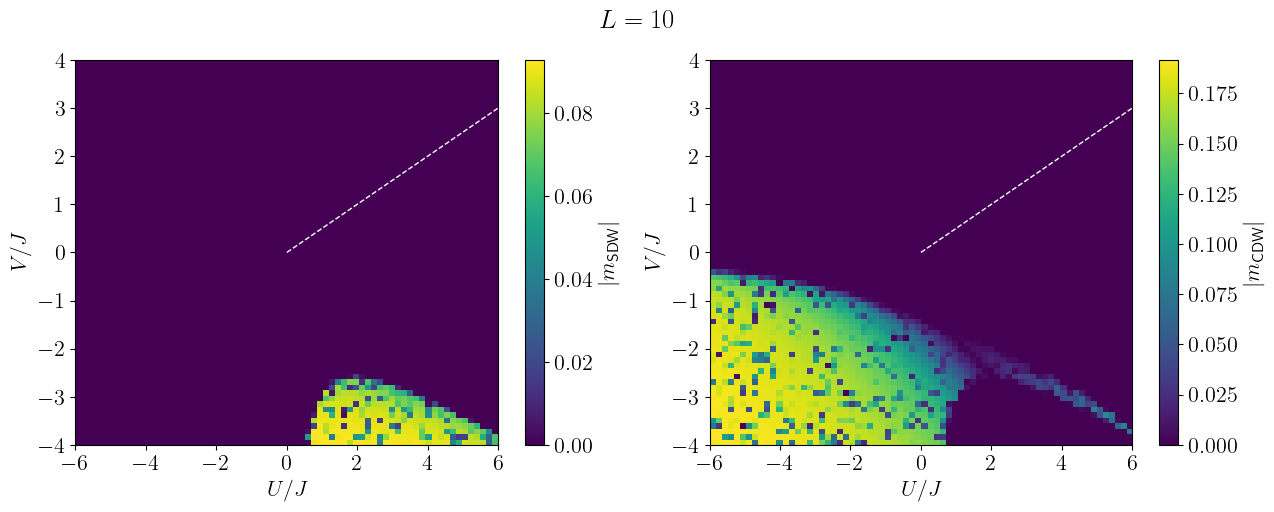

In [7]:
U_min_plot, U_max_plot = U_min , U_max
V_min_plot, V_max_plot = V_min , V_max

def select_region(U_vals, V_vals, data, U_min_plot, U_max_plot, V_min_plot, V_max_plot):
    U_mask = (U_vals >= U_min_plot) & (U_vals <= U_max_plot)
    V_mask = (V_vals >= V_min_plot) & (V_vals <= V_max_plot)
    return U_vals[U_mask], V_vals[V_mask], data[np.ix_(V_mask, U_mask)]

# Slice arrays
U_vals_plot, V_vals_plot, m_sdw_plot = select_region(U_vals, V_vals, m_sdw, U_min_plot, U_max_plot, V_min_plot, V_max_plot)
_, _, m_cdw_plot = select_region(U_vals, V_vals, m_cdw, U_min_plot, U_max_plot, V_min_plot, V_max_plot)

# Meshgrid for contours
X, Y = np.meshgrid(U_vals_plot, V_vals_plot)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
plt.suptitle(f"$L = {L}$")

# m_SDW
im0 = ax[0].imshow(m_sdw_plot, origin="lower", extent=[U_min_plot, U_max_plot, V_min_plot, V_max_plot], aspect="auto", cmap=theme)
fig.colorbar(im0, ax=ax[0], label=r"$|m_{\text{SDW}}|$")
# ax[0].contour(X, Y, np.abs(m_sdw_plot), colors='white', linestyle='--', linewidths=0.7)
ax[0].set_xlabel(r"$U / J$")
ax[0].set_ylabel(r"$V / J$")

# m_CDW
im1 = ax[1].imshow(m_cdw_plot, origin="lower", extent=[U_min_plot, U_max_plot, V_min_plot, V_max_plot], aspect="auto", cmap=theme)
fig.colorbar(im1, ax=ax[1], label=r"$|m_{\text{CDW}}|$")
# ax[1].contour(X, Y, np.abs(m_cdw_plot), colors='white', linestyle='--', linewidths=0.7)
ax[1].set_xlabel(r"$U / J$")
ax[1].set_ylabel(r"$V / J$")

# Line U = 2V
V_range = np.linspace(max(0, V_min_plot), min(U_max_plot / 2, V_max_plot), N_Points)
U_range = 2 * V_range
ax[0].plot(U_range, V_range, 'w--', linewidth=1)
ax[1].plot(U_range, V_range, 'w--', linewidth=1)

# Save and show
plt.savefig(f"{figures_path}/{model}_{exec}/order_parameters_L={L}_U={U_min_plot}-{U_max_plot}_V={V_min_plot}-{V_max_plot}.png", dpi=300, bbox_inches="tight")
plt.show()

#### Energy

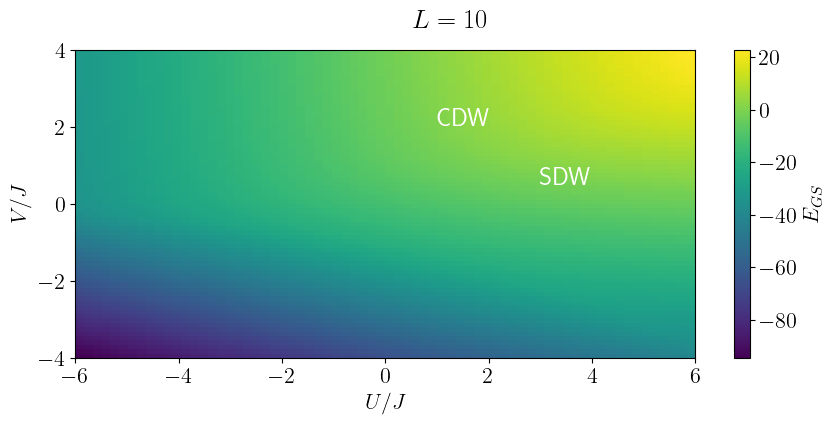

In [8]:
# Create a figure with two subplots
fig, ax = plt.subplots(1, 1, figsize=(10, 4), sharex=True)
    
im0 = ax.imshow(E_GS, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)
fig.colorbar(im0, ax=ax, label=r"$E_{GS}$")
ax.set_xlabel(r"$U / J$")
ax.set_ylabel(r"$V / J$")

# Plot line U = 2V
# V_range = np.linspace(0, U_max / 2, N_Points)
# U_range = 2 * V_range 
# ax.plot(U_range, V_range, 'w--', linewidth=1)  
    
ax.text(1, 2, "$\\text{CDW}$", color = "white", fontsize=18)
ax.text(3, 0.5, "$\\text{SDW}$", color = "white", fontsize=18)
    
plt.suptitle(f"$L = {L}$")
plt.show()
fig.savefig(f"{figures_path}/{model}_{exec}/E_GS={L}_{model}_NPoints={N_Points}.png", dpi = 500, bbox_inches='tight')

Text(0.5, 1.0, '$\\mathcal{L}_i = 1 - \\text{Tr}(\\rho_i^2)$')

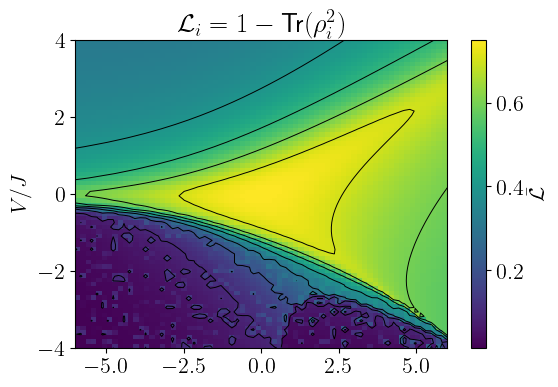

In [9]:
# Create a figure with two subplots
fig, ax1 = plt.subplots(1, 1 , figsize=(6, 4))

# Shared colorbar normalization - thanks chatgpt
# vmin = min(np.min(avg_linear_entropy), np.min(E_p))
# vmax = max(np.max(avg_linear_entropy), np.max(E_p))

U_min = np.min(U_vals)
U_max = np.max(U_vals)
V_min = np.min(V_vals)
V_max = np.max(V_max)

# Contour 
X, Y = np.meshgrid(U_vals, V_vals)

im0 = ax1.imshow(avg_linear_entropy, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)# , vmin=vmin, vmax=vmax)
fig.colorbar(im0, ax = ax1, orientation='vertical', label=r"$\bar{\mathcal{L}}$") # /\text{max}(\bar{\mathcal{L}})$")
ax1.contour(X, Y, avg_linear_entropy, colors='black', linewidths=0.7)

ax1.set_ylabel(r"$V / J$")
ax1.set_title(r"$\mathcal{L}_i = 1 - \text{Tr}(\rho_i^2)$")
# plt.suptitle(f"$L = {L}$")

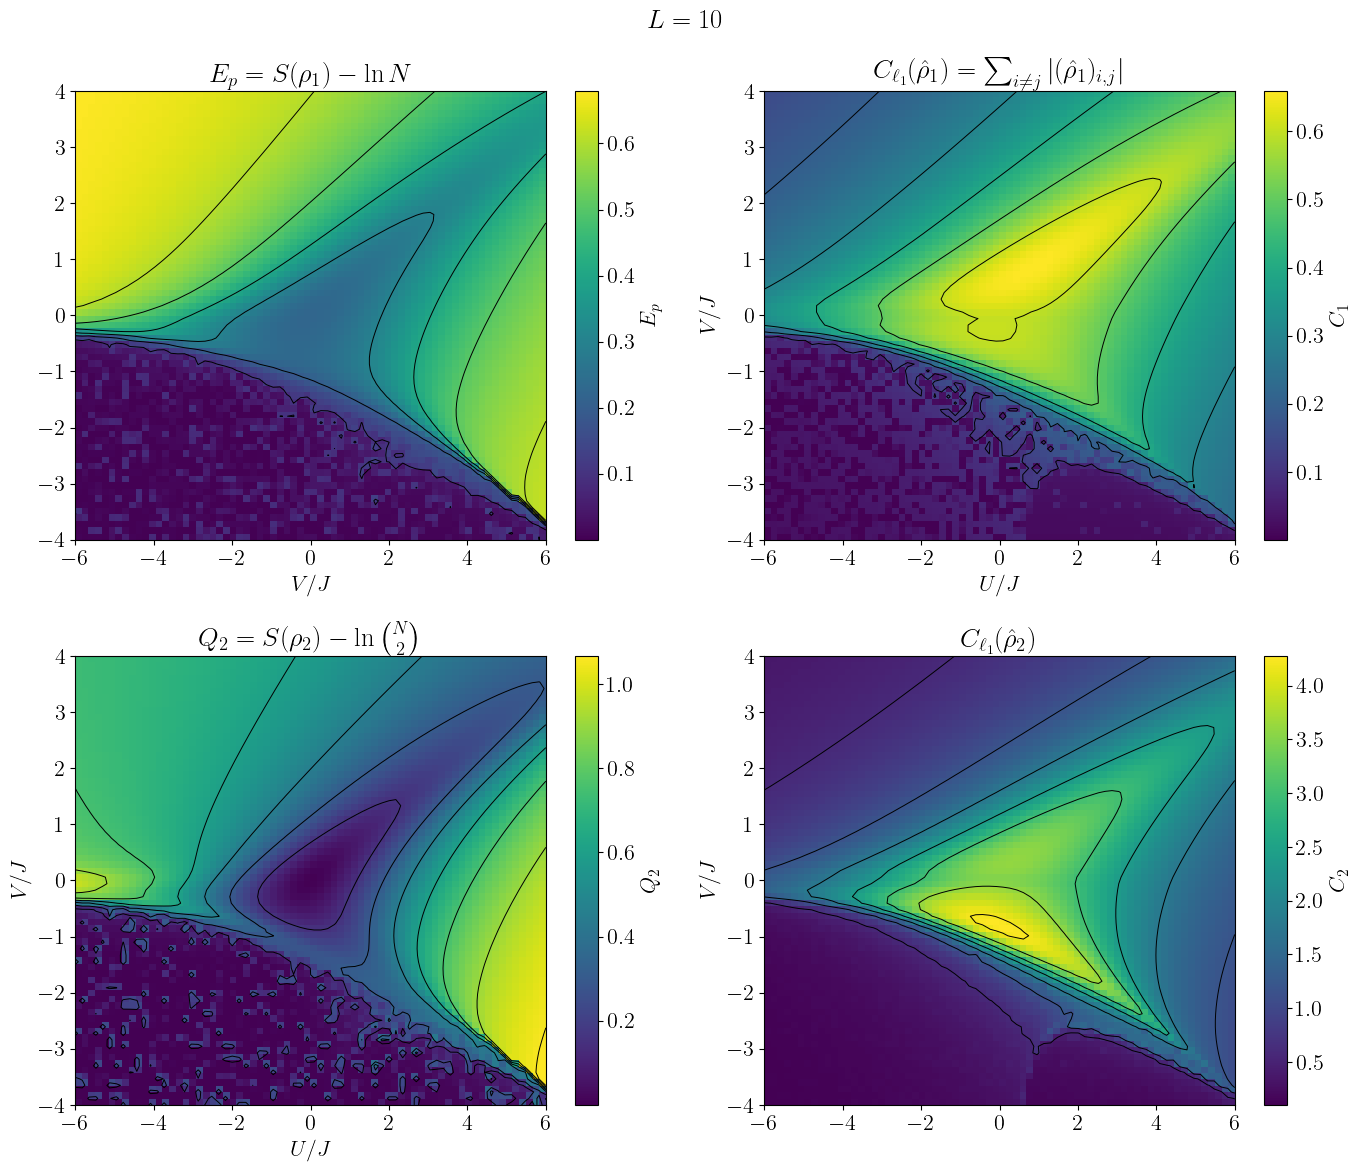

In [10]:
# Create a figure with two subplots
fig, ax1 = plt.subplots(2, 2, figsize=(14, 12))
plt.suptitle(f"$L = {L}$")

# Shared colorbar normalization - thanks chatgpt
# vmin = min(np.min(avg_linear_entropy), np.min(E_p))
# vmax = max(np.max(avg_linear_entropy), np.max(E_p))

U_min = np.min(U_vals)
U_max = np.max(U_vals)
V_min = np.min(V_vals)
V_max = np.max(V_max)

# Contour 
X, Y = np.meshgrid(U_vals, V_vals)

im1 = ax1[0, 0].imshow(E_p, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme) #  , vmin=vmin, vmax=vmax)
fig.colorbar(im1, ax = ax1[0, 0], orientation='vertical',  label=r"$E_p$") #  / \text{max}(E_{p})$")
ax1[0, 0].contour(X, Y, E_p, colors='black', linewidths=0.7)

im2 = ax1[0, 1].imshow(quantum_coherence_1, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme) #  , vmin=vmin, vmax=vmax)
fig.colorbar(im2, ax = ax1[0, 1], orientation='vertical',  label=r"$C_1$")
ax1[0, 1].contour(X, Y, quantum_coherence_1, colors='black', linewidths=0.7)

im1 = ax1[1, 0].imshow(Q_2, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme) #  , vmin=vmin, vmax=vmax)
fig.colorbar(im1, ax = ax1[1, 0], orientation='vertical',  label=r"$Q_2$") #  / \text{max}(E_{p})$")
ax1[1, 0].contour(X, Y, Q_2, colors='black', linewidths=0.7)

im1 = ax1[1, 1].imshow(quantum_coherence_2, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme) #  , vmin=vmin, vmax=vmax)
fig.colorbar(im1, ax = ax1[1, 1], orientation='vertical',  label=r"$C_2$") #  / \text{max}(E_{p})$")
ax1[1, 1].contour(X, Y, quantum_coherence_2, colors='black', linewidths=0.7)

# bar = plt.colorbar(im0, orientation='vertical', shrink=0.8, label=r"$E_p$") 
ax1[0, 0].set_xlabel(r"$U / J$")
ax1[0, 0].set_xlabel(r"$V / J$")
ax1[1, 0].set_xlabel(r"$U / J$")
ax1[0, 1].set_xlabel(r"$U / J$")

ax1[1, 0].set_ylabel(r"$V / J$")
ax1[0, 1].set_ylabel(r"$V / J$")
ax1[1, 0].set_ylabel(r"$V / J$")
ax1[1, 1].set_ylabel(r"$V / J$")

ax1[0, 0].set_title(r"$E_p = S(\rho_1) - \ln N$")
ax1[0, 1].set_title(r"$C_{\ell_1}(\hat{\rho}_1) = \sum_{i\neq j}|(\hat{\rho}_1)_{i, j}|$")
ax1[1, 0].set_title(r"$Q_2 = S(\rho_2) - \ln {N \choose 2}$")
ax1[1, 1].set_title(r"$C_{\ell_1}(\hat{\rho}_2)$")

fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_entropy_1_RDM_L={L}_NPoints={N_Points}.png", dpi=100, bbox_inches='tight')

plt.tight_layout()
plt.show()

#### Analysis of entanglement in accross different phases

In [11]:
V_targets_negatives = [-1.53, -1.32, -1.12, -0.92, -0.72]
V_targets_positives = [1.53, 2.32, 1.12, 0.92, 0.72]


U_targets_negatives = [-5.73, -4.75, -2.85, -1.76 ,-0.95, 0.0]
U_targets_positives = [2.3, 2.6, 1.9, 3.1, 4.3, 5.6]

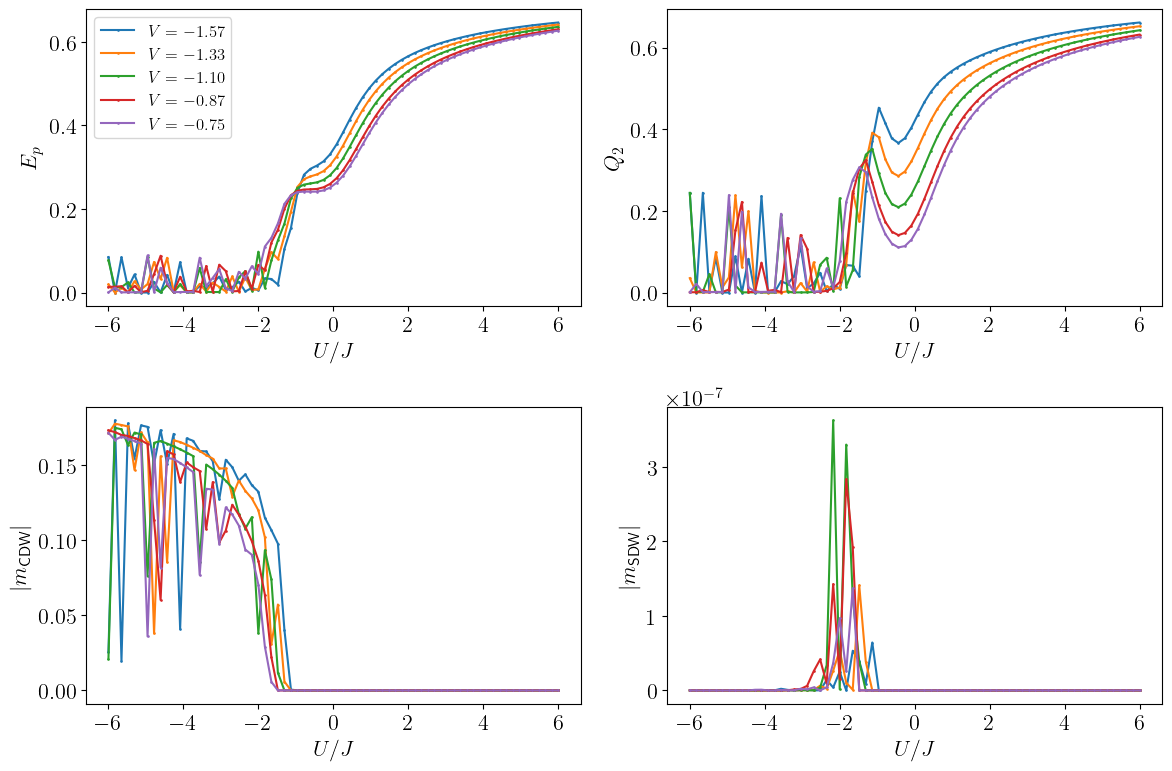

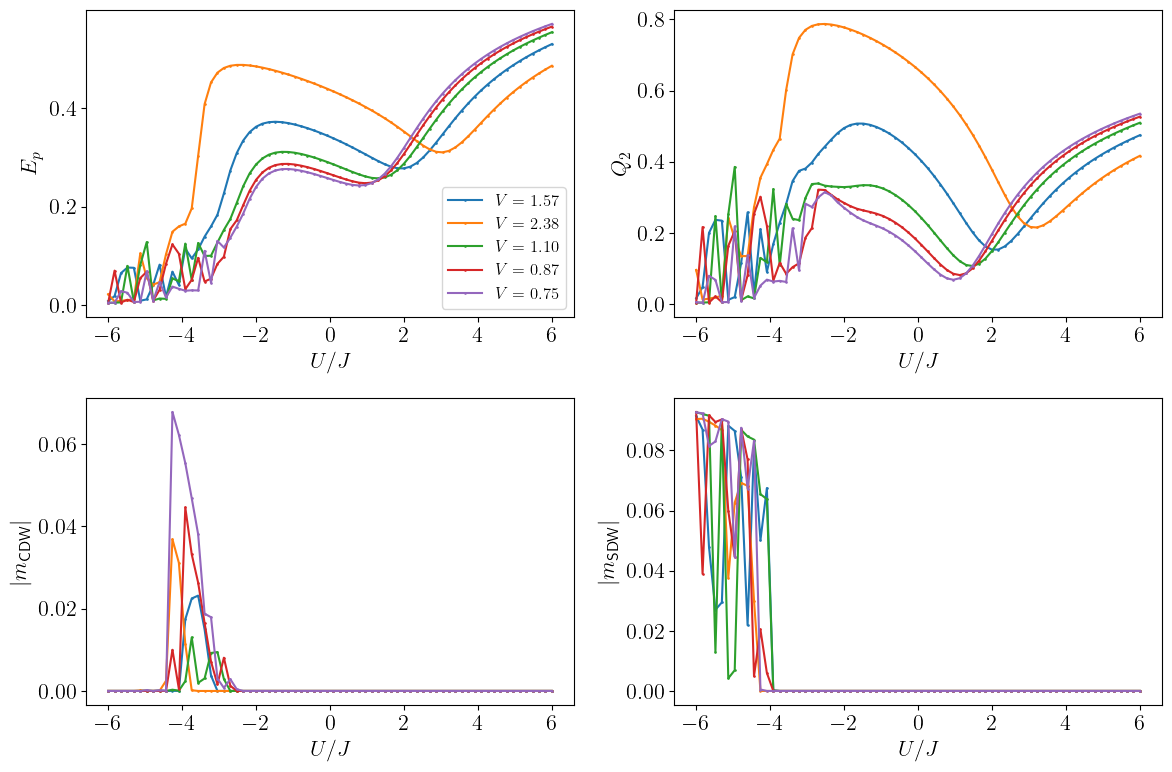

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
plt.suptitle(f"$L = {L}$")

for V_target in V_targets_negatives:
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals,   E_p[:, i_V_fixed], 'o-', markersize=0.9,  label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals,   Q_2[:, i_V_fixed], 'o-', markersize=0.9)
    ax[1, 0].plot(U_vals, m_cdw[:, i_V_fixed], 'o-', markersize=0.9)
    ax[1, 1].plot(U_vals, m_sdw[:, i_V_fixed], 'o-', markersize=0.9)

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_V_negative_.png", dpi = 500, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
 # plt.suptitle(f"$L = {L}$")

for V_target in V_targets_positives:
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals,   E_p[:, i_V_fixed], 'o-', markersize=0.9,  label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals,   Q_2[:, i_V_fixed], 'o-', markersize=0.9)
    ax[1, 0].plot(U_vals, m_cdw[:, i_V_fixed], 'o-', markersize=0.9)
    ax[1, 1].plot(U_vals, m_sdw[:, i_V_fixed], 'o-', markersize=0.9)


ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_V_positive_.png", dpi = 500, bbox_inches='tight')
plt.show()

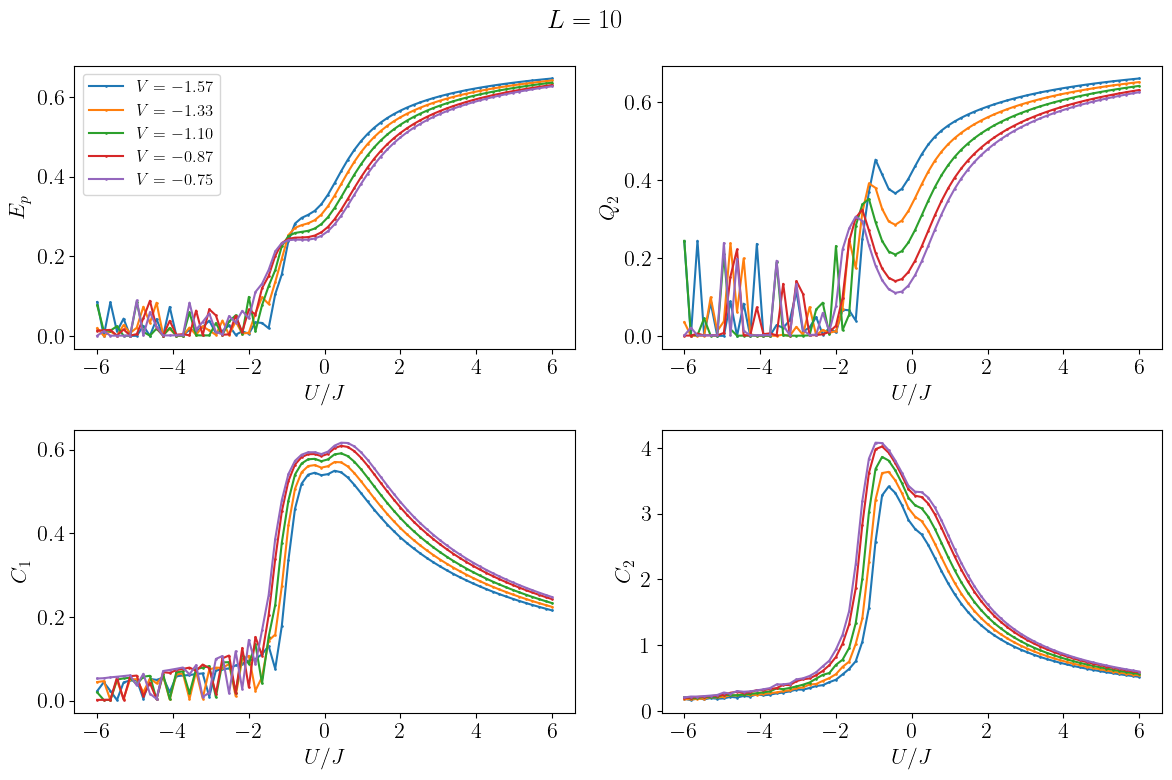

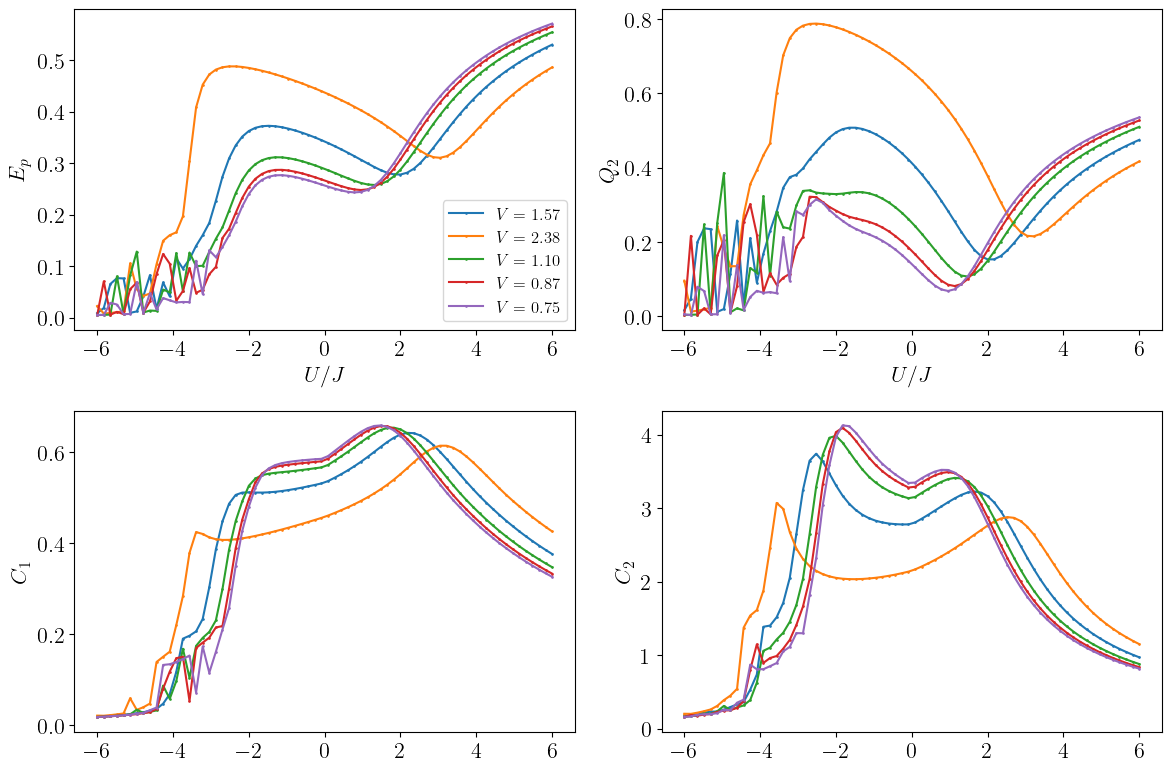

In [21]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
plt.suptitle(f"$L = {L}$")

for V_target in V_targets_negatives:
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals,   E_p[:, i_V_fixed], 'o-', markersize=0.9,  label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals,   Q_2[:, i_V_fixed], 'o-', markersize=0.9)
    ax[1, 0].plot(U_vals,   quantum_coherence_1[:, i_V_fixed], 'o-', markersize=0.9)
    ax[1, 1].plot(U_vals,   quantum_coherence_2[:, i_V_fixed], 'o-', markersize=0.9)

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$C_1$")
ax[1, 1].set_ylabel(r"$C_2$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_={L}_fixed_V_negative_.png", dpi = 500, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
 # plt.suptitle(f"$L = {L}$")

for V_target in V_targets_positives:
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals,   E_p[:, i_V_fixed], 'o-', markersize=0.9,  label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals,   Q_2[:, i_V_fixed], 'o-', markersize=0.9)
    ax[1, 0].plot(U_vals, quantum_coherence_1[:, i_V_fixed], 'o-', markersize=0.9)
    ax[1, 1].plot(U_vals, quantum_coherence_2[:, i_V_fixed], 'o-', markersize=0.9)


ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_ylabel(r"$C_1$")
ax[1, 1].set_ylabel(r"$C_2$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_={L}_fixed_V_positive_.png", dpi = 500, bbox_inches='tight')
plt.show()

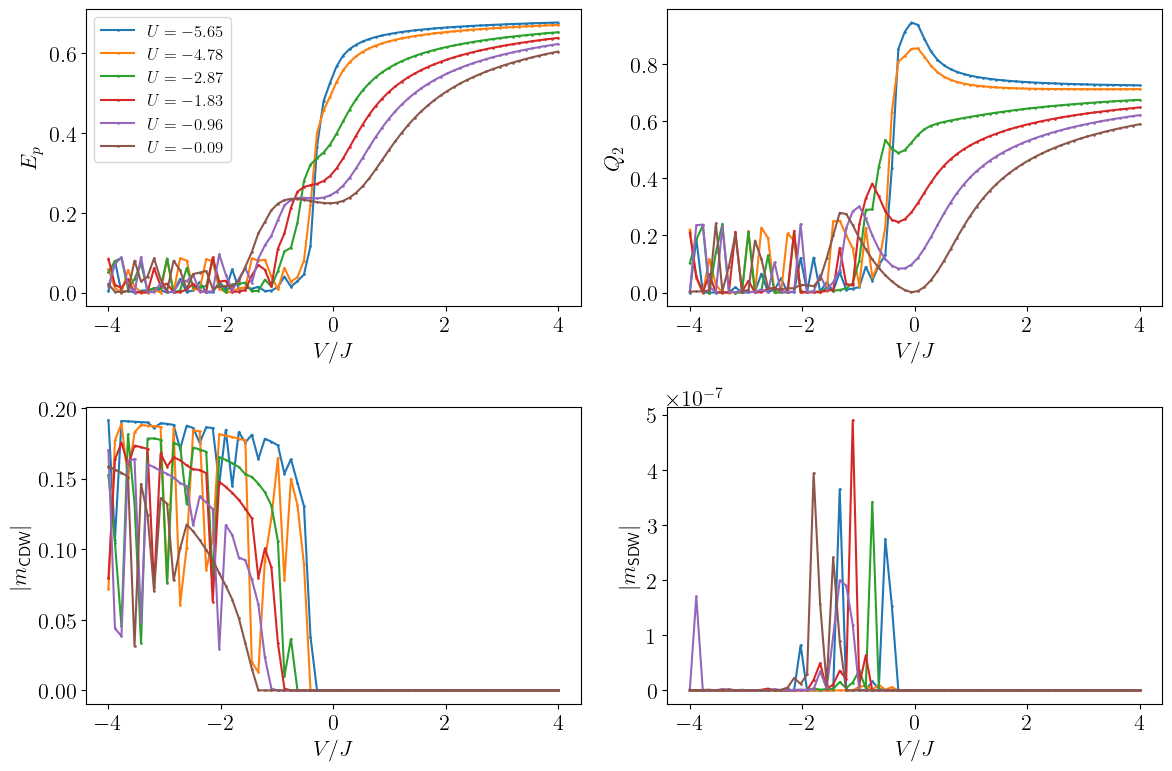

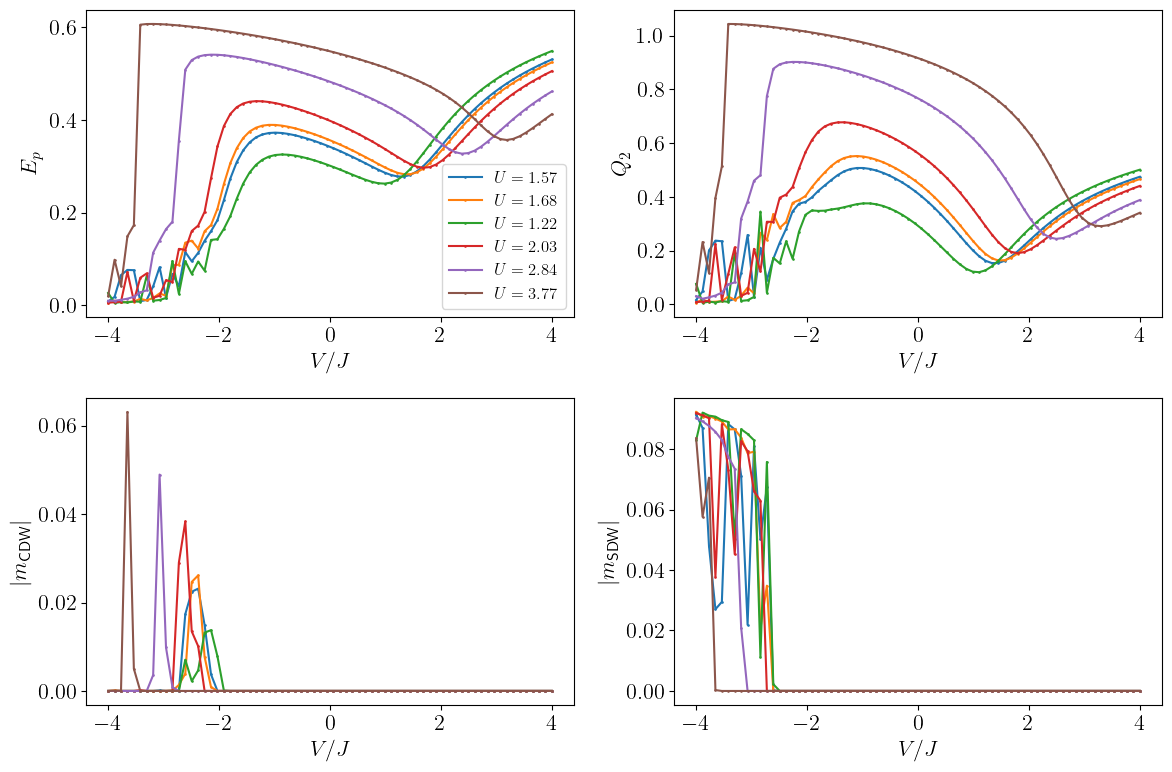

In [19]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
# plt.suptitle(f"$L = {L}$")

for U_target in U_targets_negatives:
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals,   E_p[:, i_U_fixed], 'o-', markersize=0.9,  label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[0, 1].plot(V_vals,   Q_2[:, i_U_fixed], 'o-', markersize=0.9)
    ax[1, 0].plot(V_vals, m_cdw[:, i_U_fixed], 'o-', markersize=0.9)
    ax[1, 1].plot(V_vals, m_sdw[:, i_U_fixed], 'o-', markersize=0.9)

ax[0, 0].set_xlabel(r"$V / J$")
ax[0, 1].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")
ax[1, 1].set_xlabel(r"$V / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_U_negative_.png", dpi = 500, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
 # plt.suptitle(f"$L = {L}$")

for U_target in U_targets_positives:
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals,   E_p[:, i_U_fixed], 'o-', markersize=0.9,  label=fr"$U={V_vals[i_U_fixed]:.2f}$")
    ax[0, 1].plot(V_vals,   Q_2[:, i_U_fixed], 'o-', markersize=0.9)
    ax[1, 0].plot(V_vals, m_cdw[:, i_U_fixed], 'o-', markersize=0.9)
    ax[1, 1].plot(V_vals, m_sdw[:, i_U_fixed], 'o-', markersize=0.9)

ax[0, 0].set_xlabel(r"$V / J$")
ax[0, 1].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")
ax[1, 1].set_xlabel(r"$V / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_U_positive_.png", dpi = 500, bbox_inches='tight')
plt.show()

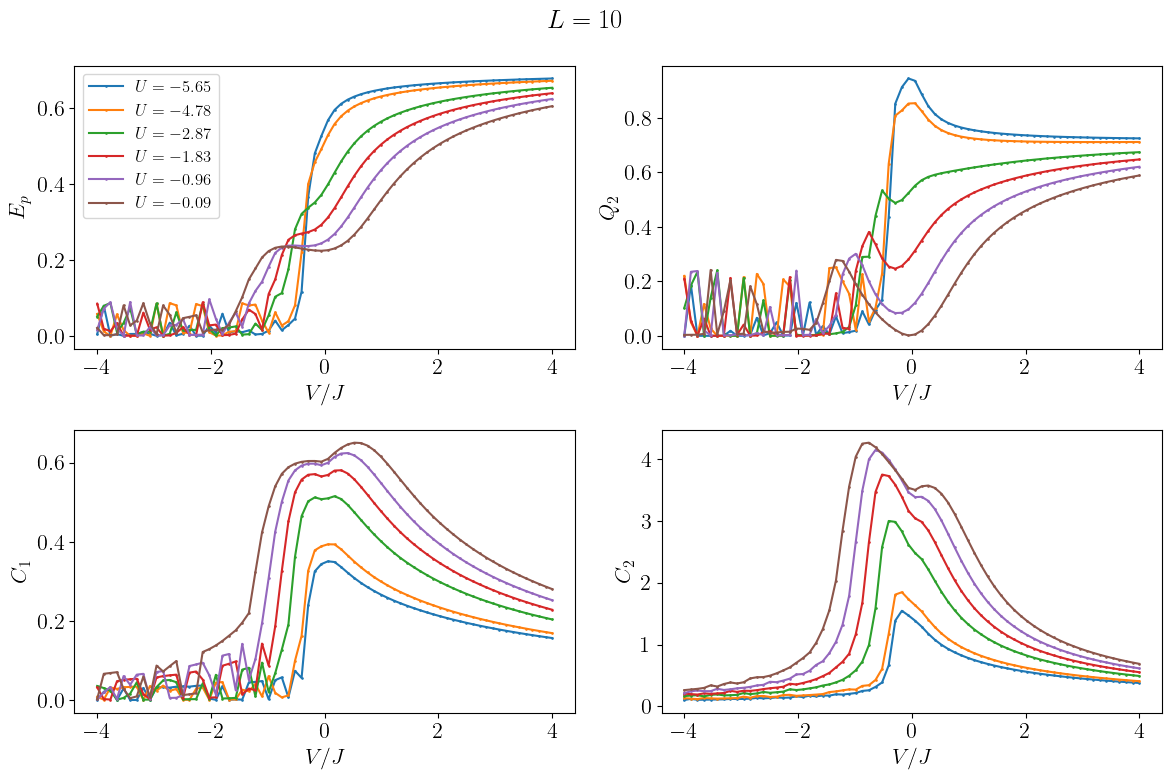

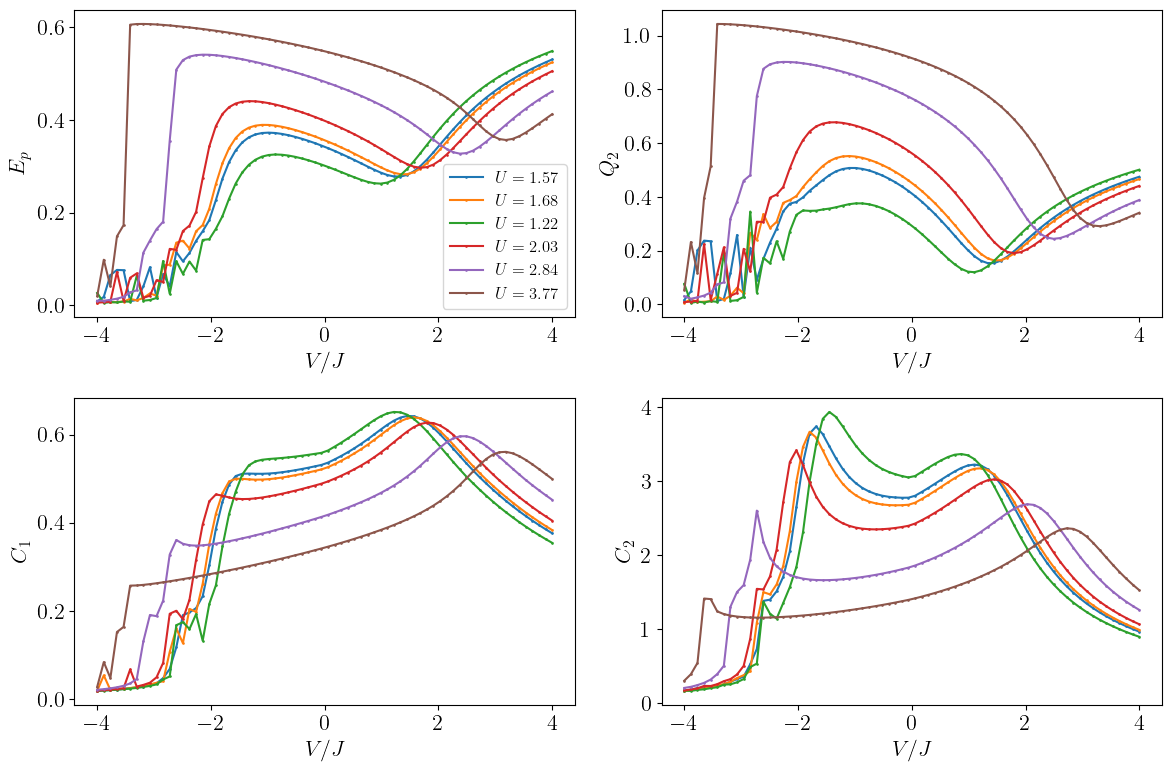

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
plt.suptitle(f"$L = {L}$")

for U_target in U_targets_negatives:
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals,   E_p[:, i_U_fixed], 'o-', markersize=0.9,  label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[0, 1].plot(V_vals,   Q_2[:, i_U_fixed], 'o-', markersize=0.9)
    ax[1, 0].plot(V_vals, quantum_coherence_1[:, i_U_fixed], 'o-', markersize=0.9)
    ax[1, 1].plot(V_vals, quantum_coherence_2[:, i_U_fixed], 'o-', markersize=0.9)

ax[0, 0].set_xlabel(r"$V / J$")
ax[0, 1].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")
ax[1, 1].set_xlabel(r"$V / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$C_1$")
ax[1, 1].set_ylabel(r"$C_2$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_={L}_fixed_U_negative_.png", dpi = 500, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
 # plt.suptitle(f"$L = {L}$")

for U_target in U_targets_positives:
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals,   E_p[:, i_U_fixed], 'o-', markersize=0.9,  label=fr"$U={V_vals[i_U_fixed]:.2f}$")
    ax[0, 1].plot(V_vals,   Q_2[:, i_U_fixed], 'o-', markersize=0.9)
    ax[1, 0].plot(V_vals, quantum_coherence_1[:, i_U_fixed], 'o-', markersize=0.9)
    ax[1, 1].plot(V_vals, quantum_coherence_2[:, i_U_fixed], 'o-', markersize=0.9)

ax[0, 0].set_xlabel(r"$V / J$")
ax[0, 1].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")
ax[1, 1].set_xlabel(r"$V / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$C_1$")
ax[1, 1].set_ylabel(r"$C_2$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_={L}_fixed_U_positive_.png", dpi = 500, bbox_inches='tight')
plt.show()